In [1]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter


%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/{model}_{exec}/XXXXX"

In [2]:
N_Points = 50
L = 5

In [3]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 =           df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    avg_linear_entropy = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p =           df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS =         df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, avg_linear_entropy, Q_2, Q_2_bits, quantum_coherence_2

In [4]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [5]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [6]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [7]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

Don't know why, but this order parameters computed in the julia code give the wrong $|m_{\text{SDW}}|$ and $|m_{\text{CDW}}|$...
Saving the magnetization and charge density made possible to compute in python.

### Order parameters for spin-density wave and charge-density wave

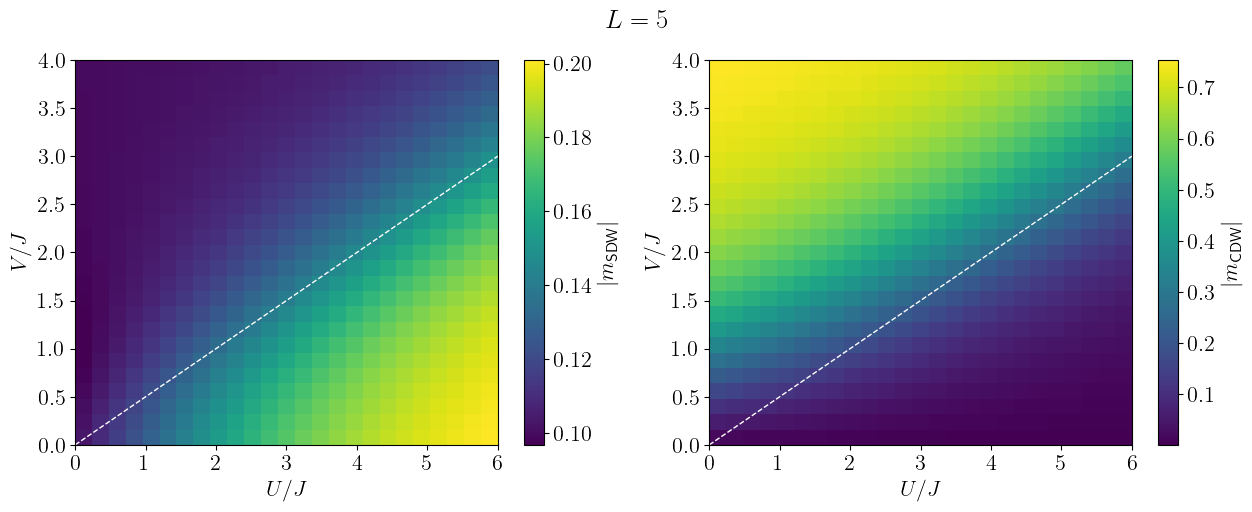

In [8]:
U_min_plot, U_max_plot = 0 , U_max
V_min_plot, V_max_plot = 0 , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(m_sdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(m_cdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
V_targets_negatives = np.sort([-1.53, -1.32, -1.12, -0.92, -0.72,  -0.6])
V_targets_positives = np.sort([0.1, 0.9, 1.6, 2.32, 1.12, 1.7, 2.1, 3.0])
U_targets_negatives = np.sort([-5.73, -4.75, -2.85, -1.76 ,-0.95, 0.0])
U_targets_positives = np.sort([2.3, 2.6, 0.1, 0.5, 1.5, 3.1, 4.3, 6.0])

# transposing the data was only needed to make the full diagram
Q_2 =           df['Q_2'].values.reshape(nV, nU)# .T

quantum_coherence_1 = df['coh_1rdm'].values.reshape(nV, nU)# .T
quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU)# .T

E_p =           df['E_p'].values.reshape(nV, nU)# .T

IndexError: index 15 is out of bounds for axis 0 with size 6

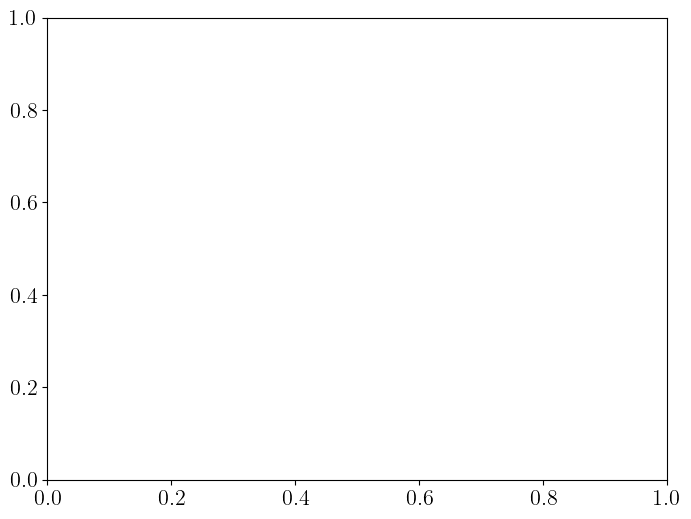

In [10]:
def plot_cut_phase_diagram(measures, x_vals, all_vals, targets, fixed_val_label):

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    # plt.suptitle(f"$L = {L}$")
    colors_neg = cm.viridis(np.linspace(0, 1, len(targets)))

    for color, target in zip(colors_neg, targets):
        i_fixed = np.argmin(np.abs(all_vals - target))
        ax.plot(x_vals, measures[:, i_fixed], 'o-', markersize=0.9, color=color, label=fr"${fixed_val_label}={targets[i_fixed]:.2f}$")

    ax.set_xlabel(r"$U / J$")
    ax.set_xlabel(r"$U / J$")
    ax.set_ylabel(r"$E_p$")
    ax.legend(fontsize=12)
    plt.tight_layout()
    # fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png",
    #            dpi=500, bbox_inches='tight')
    plt.show()

plot_cut_phase_diagram(E_p, U_vals, V_vals, V_targets_negatives, "V")

#### Fixed $V$ values

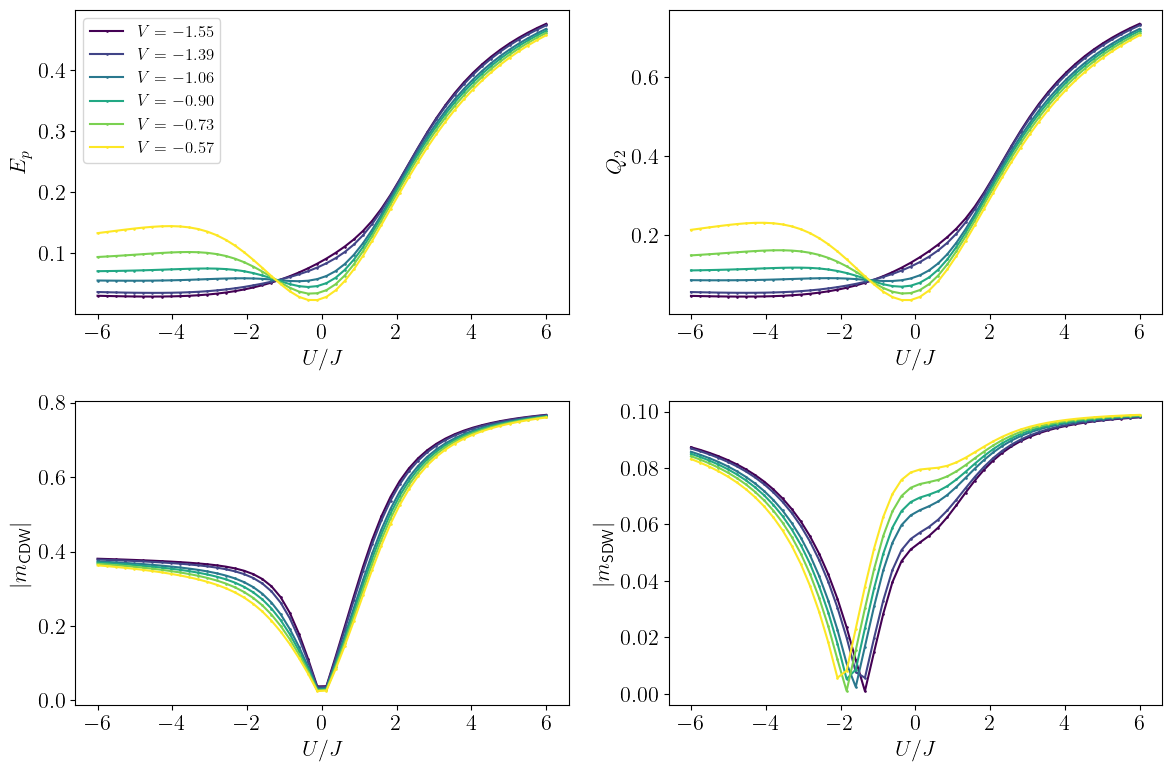

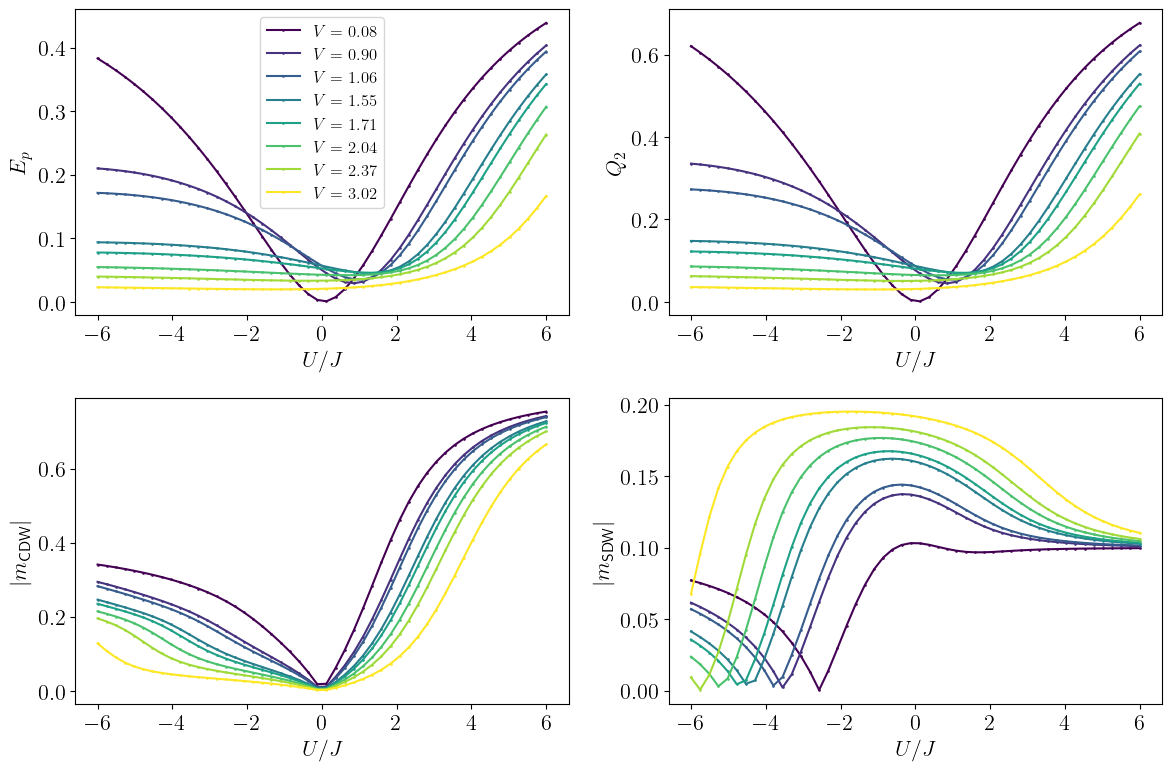

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()

# Positive V plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

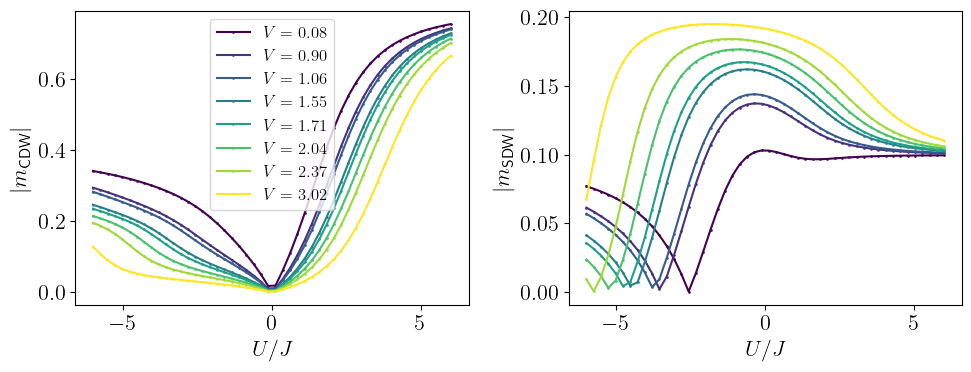

In [ ]:
# Positive V plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=f"$V={V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].set_xlabel(r"$U / J$")
ax[1].set_xlabel(r"$U / J$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

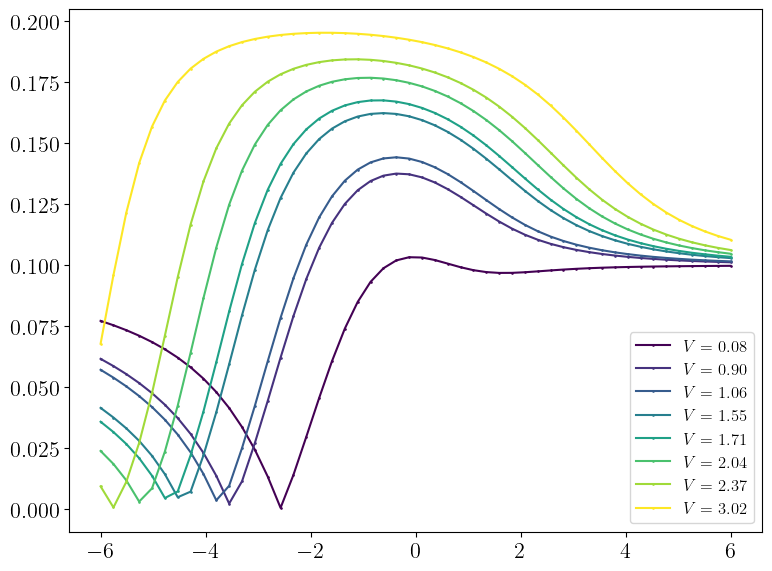

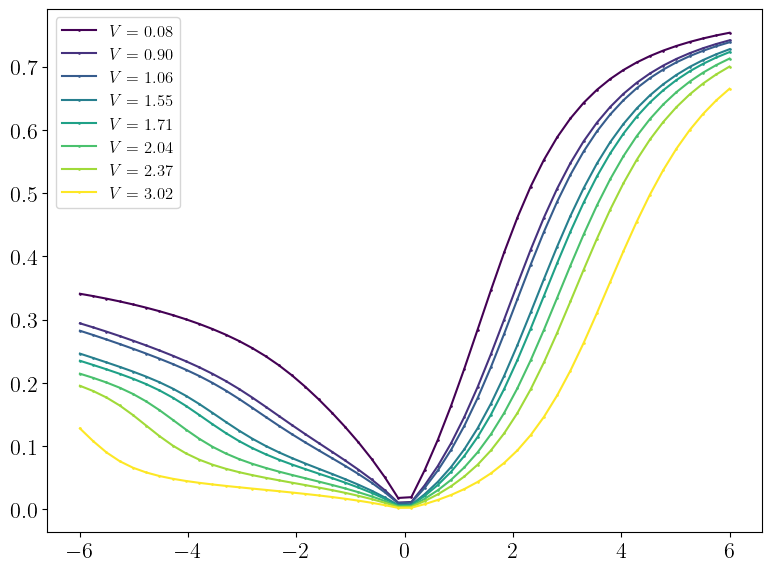

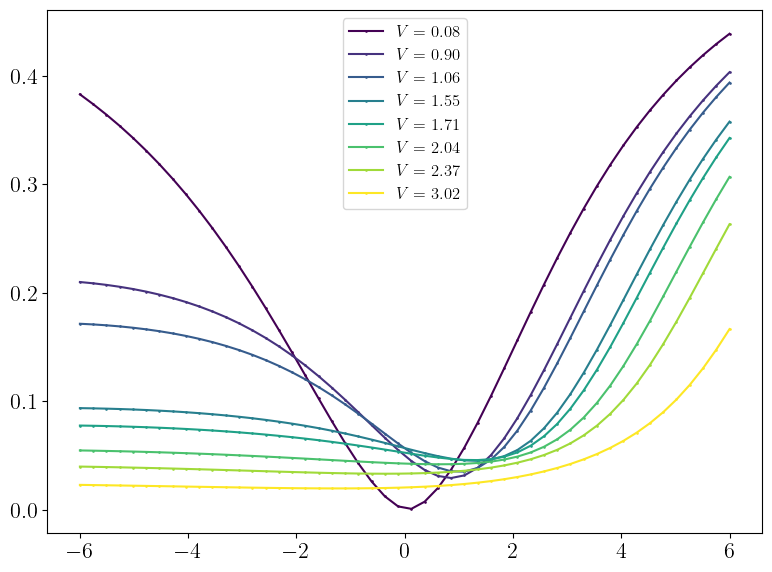

In [ ]:
def plot_cut_phase_diagram(measure, x_vals, all_vals, targets, fixed_val_label, fname, axis = 1):
    # Positive V plots
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    colors_pos = cm.viridis(np.linspace(0, 1, len(targets)))

    # In some measures [:, axis] in others [axis, :]. This fixes it.
    data = np.moveaxis(measure, axis, 1)

    for color, target in zip(colors_pos, targets):
        i_fixed = np.argmin(np.abs(all_vals - target))
        ax.plot(x_vals, data[:, i_fixed], 'o-', markersize=0.9, color=color, label=fr"${fixed_val_label}={all_vals[i_fixed]:.2f}$")

    # ax.set_ylabel(r"$|m_{\text{CDW}}|$")
    # ax.set_xlabel(r"$U / J$")
    ax.legend(fontsize=12)

    plt.tight_layout()
    fig.savefig(f"{fname}", dpi=100, bbox_inches='tight')
    plt.show()

plot_cut_phase_diagram(m_sdw, U_vals, V_vals, V_targets_positives, "V", 
                fig_path.replace("XXXXX", f"m_sdw_={L}_fixed_V_positive_.png"), axis = 1)
plot_cut_phase_diagram(m_cdw, U_vals, V_vals, V_targets_positives, "V", 
                fig_path.replace("XXXXX", f"m_cdw_L={L}_fixed_V_Positive.png"), axis = 1)

plot_cut_phase_diagram(E_p, U_vals, V_vals, V_targets_positives, "V", 
                fig_path.replace("XXXXX", f"m_cdw_L={L}_fixed_V_Positive.png"), axis = 1)

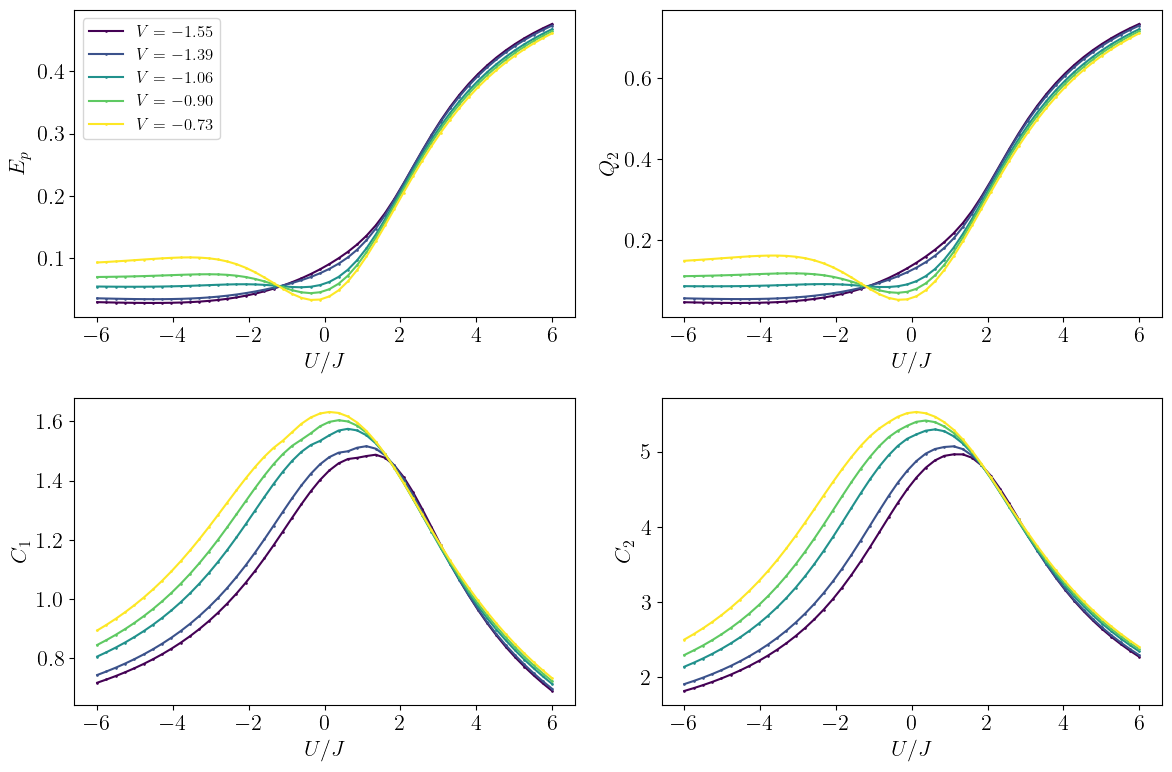

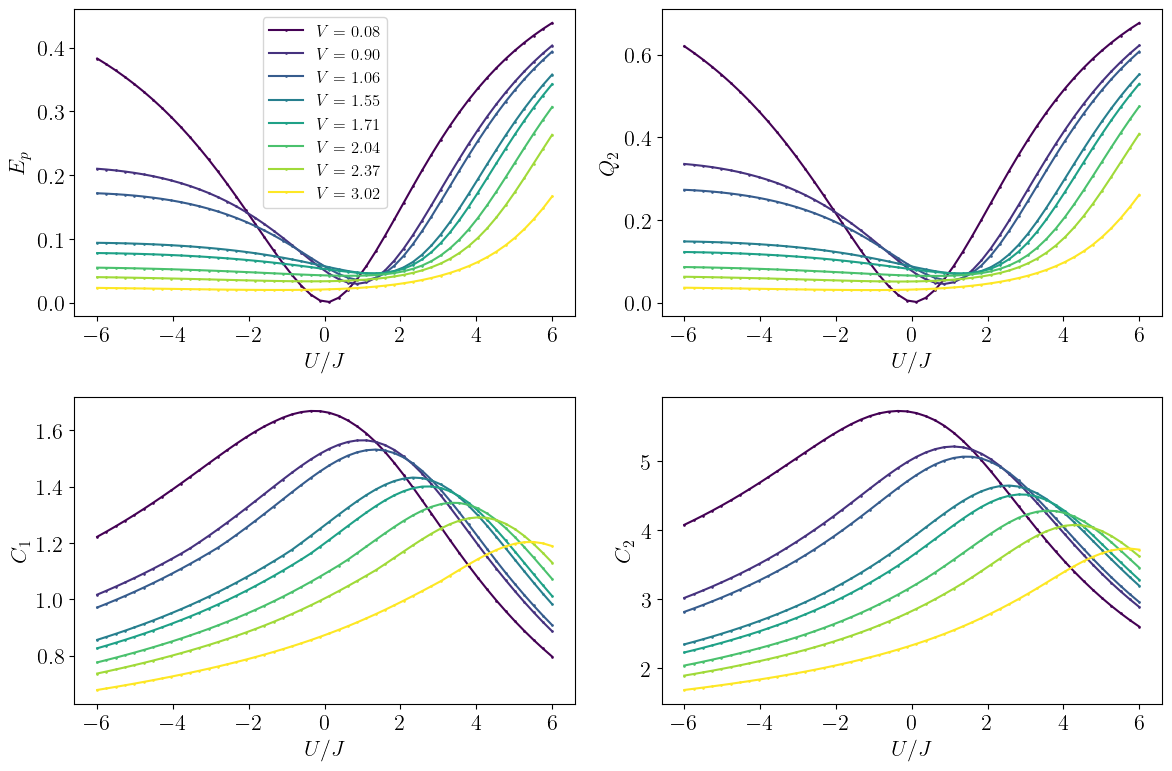

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

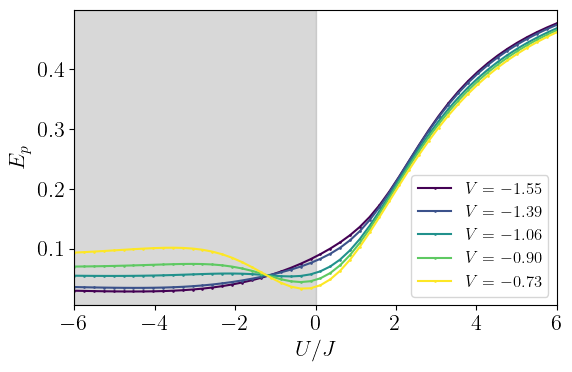

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

# Manually set the x-axis limits after plotting all data
ax.set_xlim(U_vals.min(), U_vals.max())

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

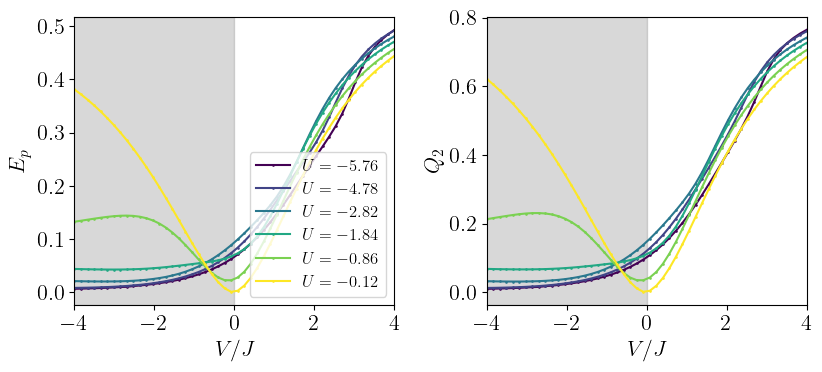

In [ ]:
# Assuming all necessary variables are defined
# cm, U_targets_negatives, U_vals, V_vals, E_p, Q_2, figures_path, model, exec, and L
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax[0].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)
ax[1].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

# Manually set the x-axis limits after plotting all data
ax[0].set_xlim(V_vals.min(), V_vals.max())
ax[1].set_xlim(V_vals.min(), V_vals.max())

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")
ax[0].set_ylabel(r"$E_p$")
ax[1].set_ylabel(r"$Q_2$")

ax[0].legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

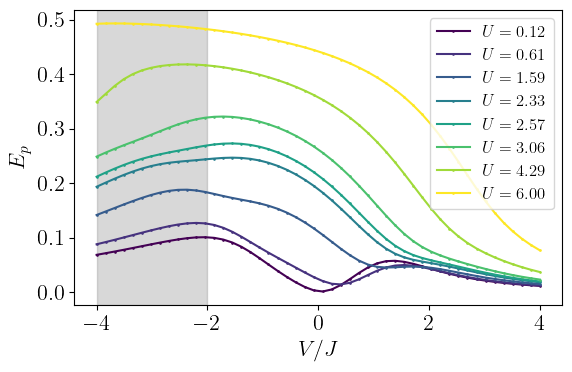

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")
# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-4.0, -2.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

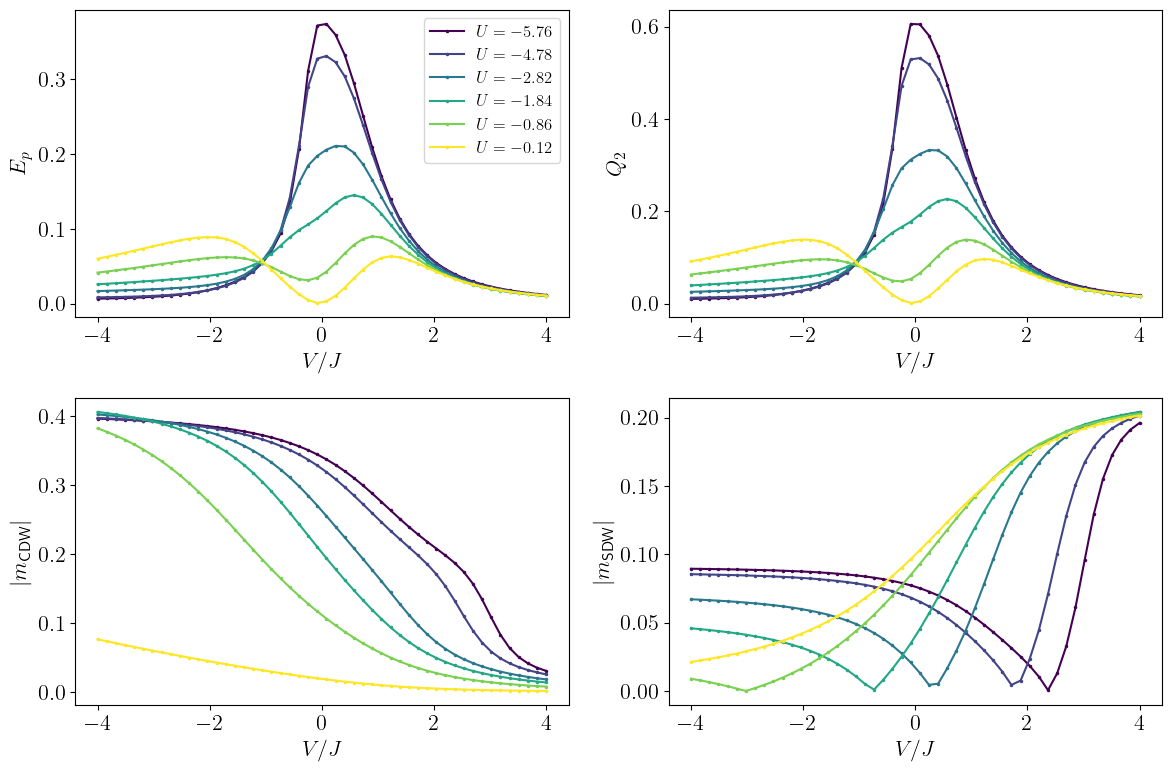

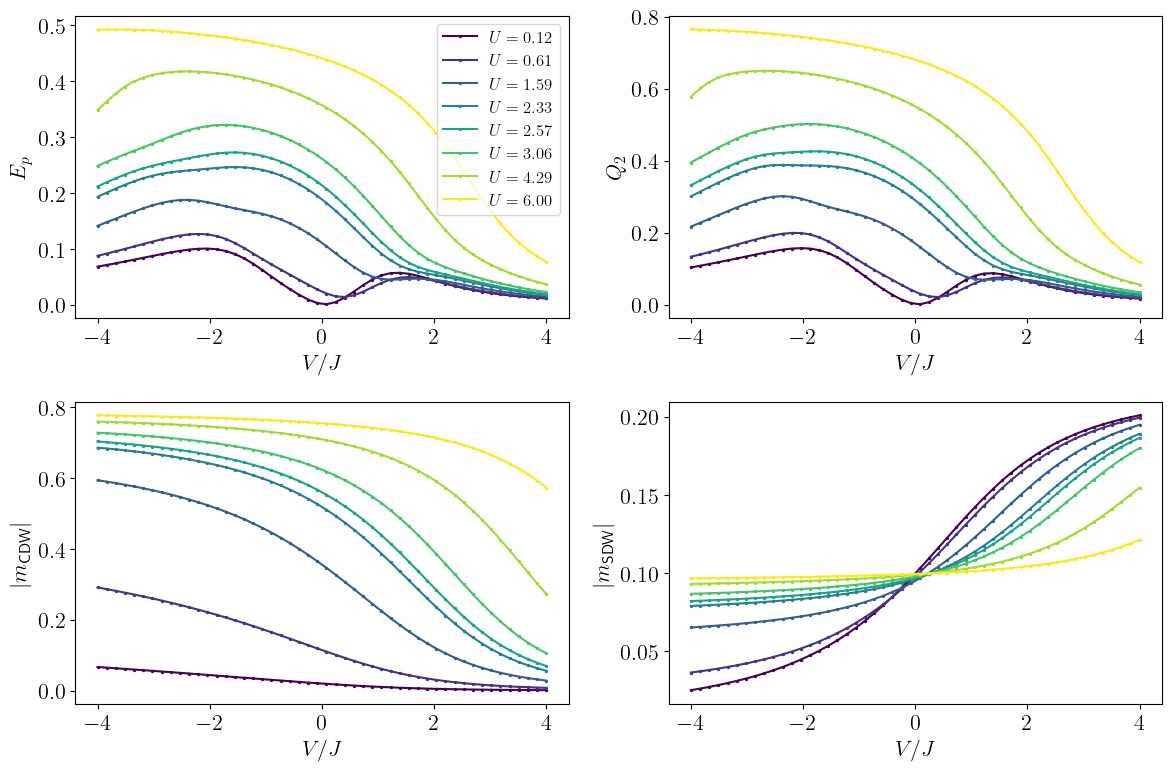

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[i_U_fixed, :], 'o-',   markersize=1.5, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[i_U_fixed, :], 'o-',   markersize=1.5, color=color)
    ax[1, 0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.5, color=color)
    ax[1, 1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=1.5, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[i_U_fixed, :], 'o-', markersize=1.4, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[i_U_fixed, :], 'o-', markersize=1.4, color=color)
    ax[1, 0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.4, color=color)
    ax[1, 1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=1.4, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

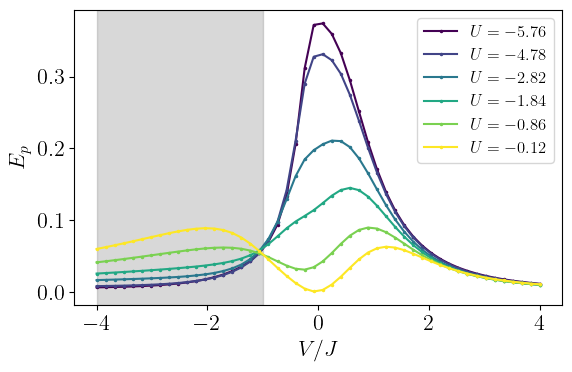

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

ax.axvspan(-4.0, -1.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=1.5, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm_L={L}_fixed_U_positive.png", dpi=500, bbox_inches='tight')
plt.show()


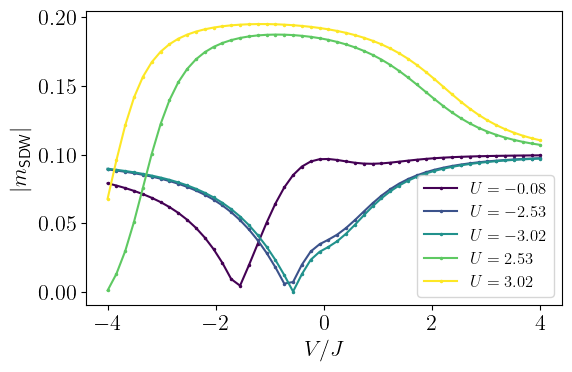

In [ ]:
V_targets = [0, -2.5, -3, 2.5, 3]

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

for color, V_target in zip(colors_neg, V_targets):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(V_vals, m_sdw[:, i_V_fixed], 'o-', markersize=1.5, color=color, label=fr"$U={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$|m_{\text{SDW}}|$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/m_sdw_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

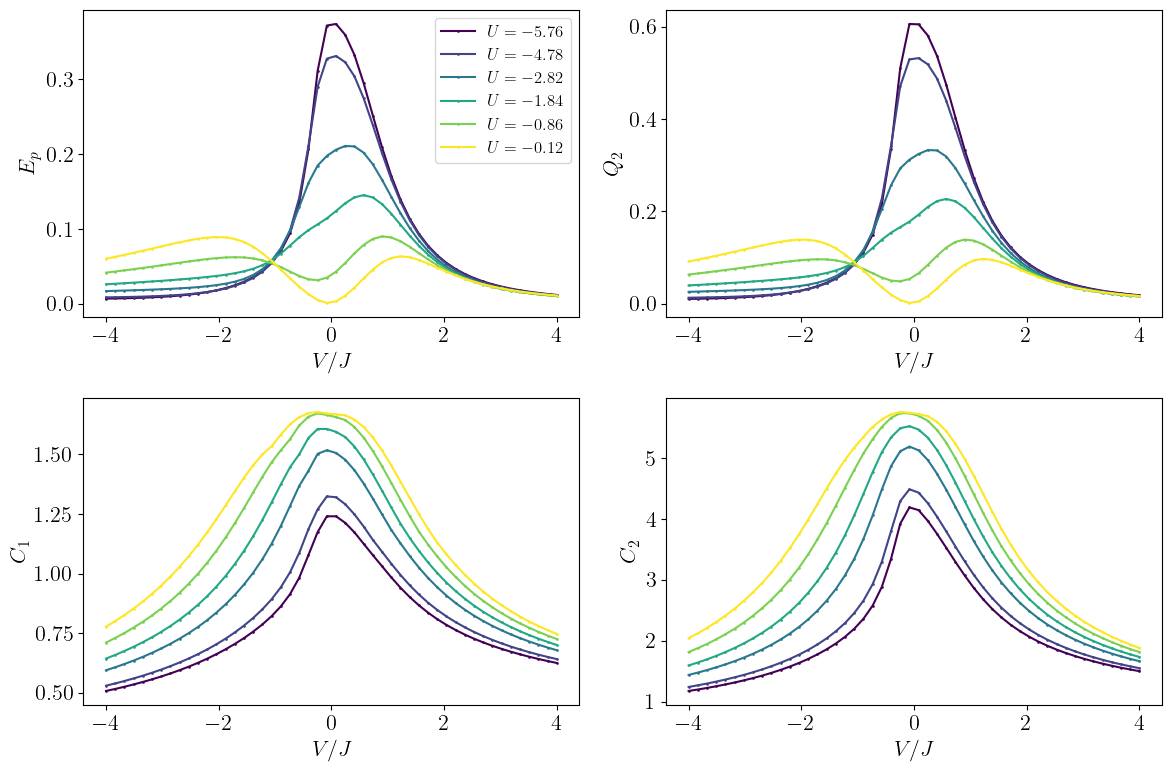

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,                 Q_2[i_U_fixed, :], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[i_U_fixed, :], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


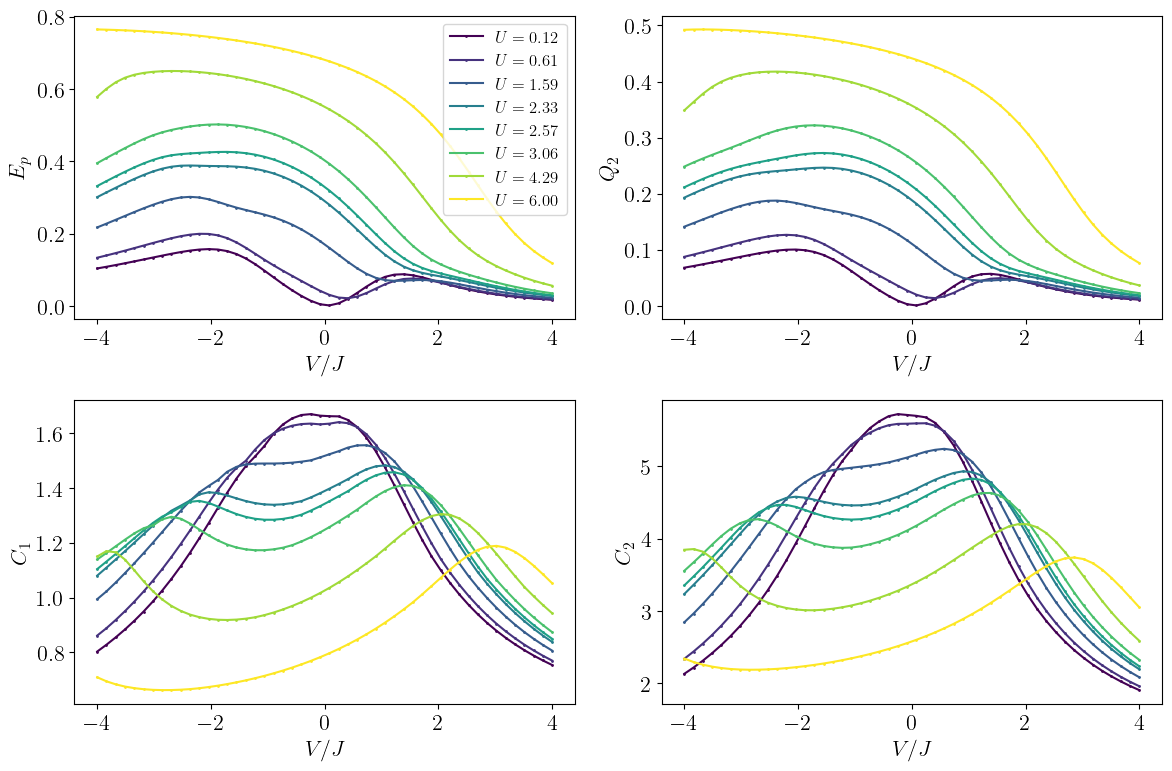

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 Q_2[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=1.0, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=1.0, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[i_U_fixed, :], 'o-', markersize=1.0, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

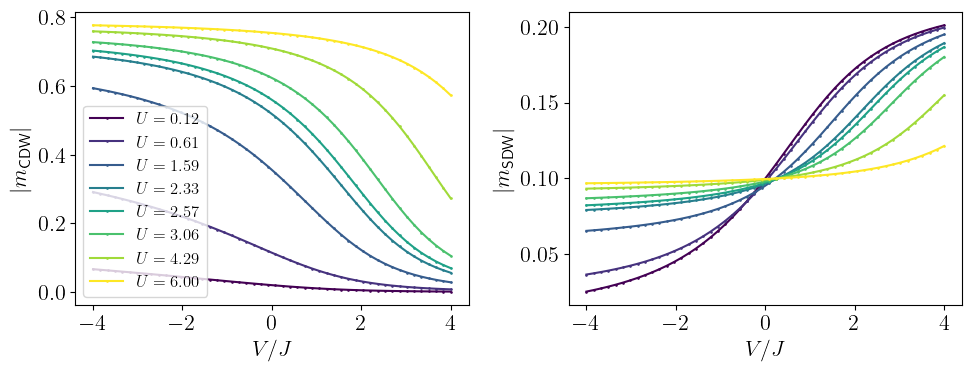

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

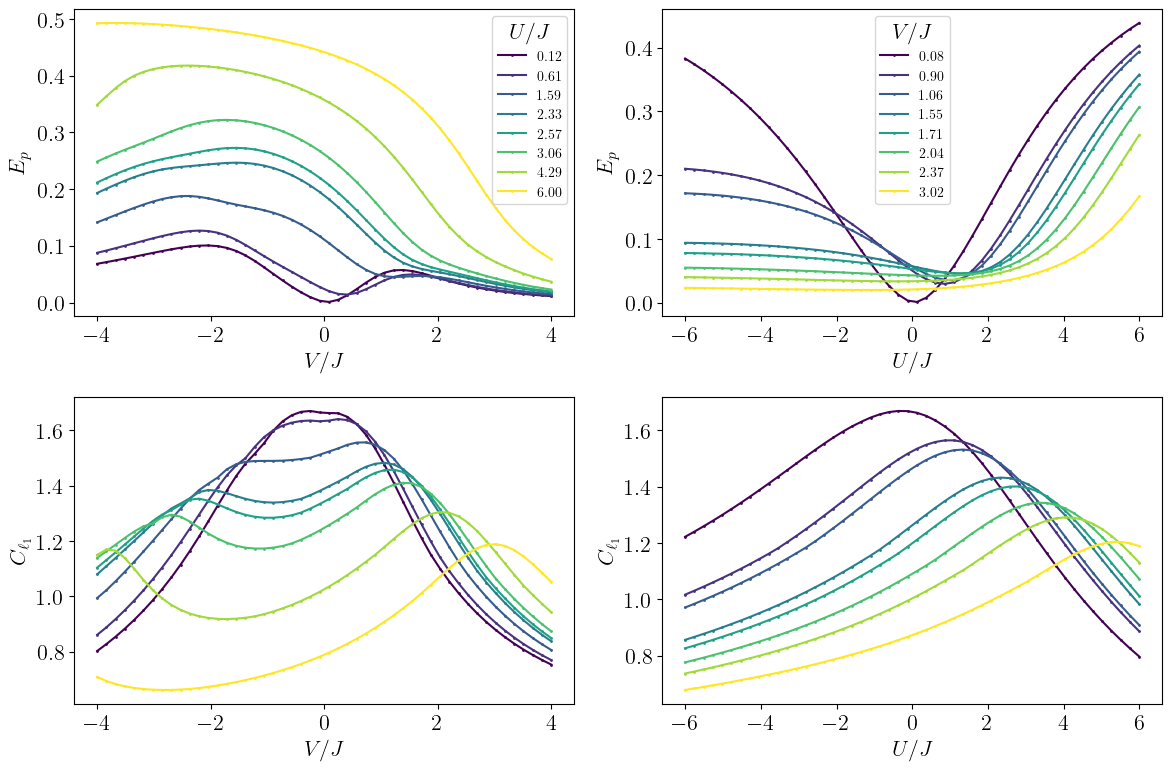

In [ ]:
colors_U = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, U_target in zip(colors_U, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"${U_vals[i_U_fixed]:.2f}$")
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=1.0, color=color)

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 1].plot(U_vals,                 E_p[:, i_V_fixed], 'o-', markersize=1.0, color=color,  label=fr"${V_vals[i_V_fixed]:.2f}$")
    ax[1, 1].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=1.0, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[1, 0].set_ylabel(r"$C_{\ell_1}$")
ax[0, 0].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")

ax[0, 1].set_ylabel(r"$E_p$")
ax[1, 1].set_ylabel(r"$C_{\ell_1}$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

# ---- Legends ----
ax[0, 0].legend(fontsize=10, title=r"$U/J$", loc='best')
ax[0, 1].legend(fontsize=10, title=r"$V/J$", loc='best')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_combined_{L}.png", dpi=500, bbox_inches='tight')
plt.show()

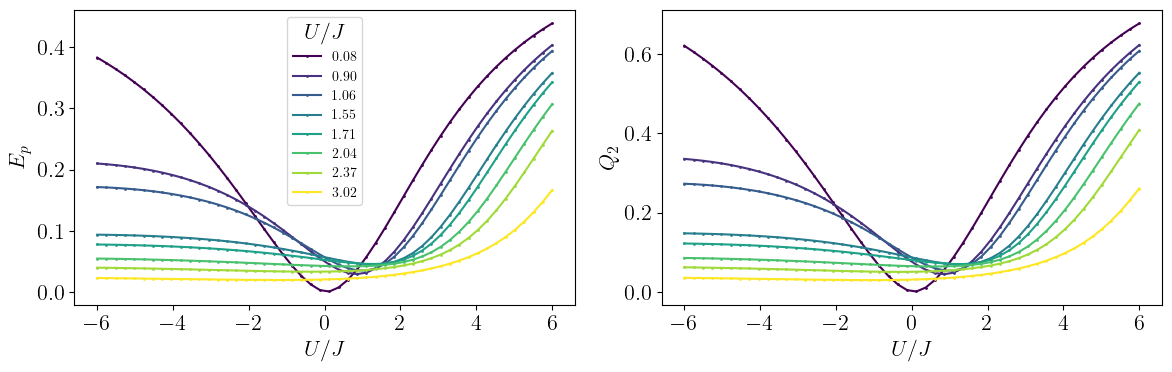

In [ ]:
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals,                 E_p[:, i_V_fixed], 'o-', markersize=1.0, color=color, label=fr"${V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals,                 Q_2[:, i_V_fixed], 'o-', markersize=1.0, color=color)

ax[0].set_ylabel(r"$E_p$")
ax[0].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$Q_2$")
ax[1].set_xlabel(r"$U / J$")

# ---- Legends ----
ax[0].legend(fontsize=10, title=r"$U/J$", loc='best')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_combined_{L}.png", dpi=500, bbox_inches='tight')
plt.show()

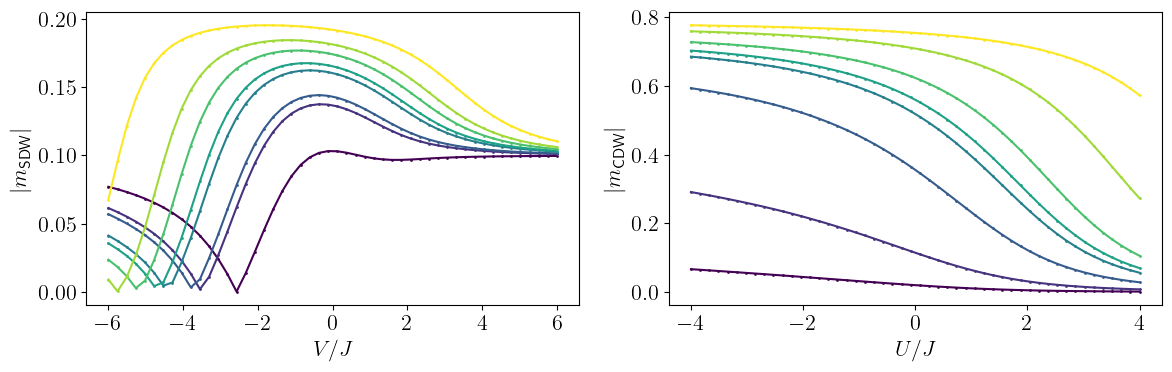

In [ ]:
colors_U = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for color, U_target in zip(colors_U, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[1].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"${U_vals[i_U_fixed]:.2f}$")

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals,  m_sdw[:, i_V_fixed], 'o-', markersize=1.0, color=color,  label=fr"${V_vals[i_V_fixed]:.2f}$")

ax[0].set_ylabel(r"$|m_{\text{SDW}}|$")
ax[0].set_xlabel(r"$V / J$")

ax[1].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_xlabel(r"$U / J$")

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_combined_L={L}.png", dpi=500, bbox_inches='tight')
plt.show()